# MetroPT-3 Dataset: Synthetic Data Generation
Having identified the time-based domains as the farthest in all selected metrics, and having observed that the transfer learning performance is affected by the distance between domains, we generate synthetic data to bridge the gap between the source and target domains. The synthetic data generation process involves creating new samples that mimic the characteristics of the target domain while leveraging the knowledge from the source domain.

In [ ]:
import os
import ot
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.linalg
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tqdm.auto import tqdm


sns.set_theme(style='whitegrid', palette='muted')

# ── Data Loading ──
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_FILE = os.path.join(PROJECT_ROOT, 'data', 'MetroPT3(AirCompressor).csv')

FAILURES = {
    1: {'type': 'Air Leak', 'start': '2020-04-18 00:00:00', 'end': '2020-04-18 23:59:00'},
    2: {'type': 'Air Leak', 'start': '2020-05-29 23:30:00', 'end': '2020-05-30 06:00:00'},
    3: {'type': 'Air Leak', 'start': '2020-06-05 10:00:00', 'end': '2020-06-07 14:30:00'},
    4: {'type': 'Air Leak', 'start': '2020-07-15 14:30:00', 'end': '2020-07-15 19:00:00'}
}

df = pd.read_csv(DATA_FILE, index_col=0, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)
df['Anomaly'] = 0
for failure_id, info in FAILURES.items():
    start = pd.to_datetime(info['start'])
    end = pd.to_datetime(info['end'])
    df.loc[start:end, 'Anomaly'] = 1

ANALOG_SENSORS = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']

# ── Season Assignment ──
def assign_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Other'

df['Month'] = df.index.month
df['Season'] = df['Month'].apply(assign_season)

# ── Focus on the hardest domain pair: Spring → Summer ──
source_domain = df[df['Season'] == 'Spring']
target_domain = df[df['Season'] == 'Summer']

print(f"Source (Spring): {len(source_domain)} rows | Anomalies: {source_domain['Anomaly'].sum()}")
print(f"Target (Summer): {len(target_domain)} rows | Anomalies: {target_domain['Anomaly'].sum()}")

Source (Spring): 641982 rows | Anomalies: 11017
Target (Summer): 659586 rows | Anomalies: 18937


## 1. Data Preparation

We extract the anomalous datapoints from the Spring (Source) and Summer (Target) domains, and standardize them. We focus exclusively on anomalies because >98% of the dataset is Normal, and global metrics would mask the concept drift of the anomalies themselves.

In [ ]:
# Extract and standardize anomalies from both domains
src_anom = source_domain[source_domain['Anomaly'] == 1][ANALOG_SENSORS].values
tgt_anom = target_domain[target_domain['Anomaly'] == 1][ANALOG_SENSORS].values

scaler = StandardScaler()
all_anom = np.vstack([src_anom, tgt_anom])
all_scaled = scaler.fit_transform(all_anom)

src_scaled = all_scaled[:len(src_anom)]
tgt_scaled = all_scaled[len(src_anom):]

# Prepare references for TL evaluation
source_spring = source_domain.copy()
target_summer = target_domain.copy()

print(f"Spring anomalies: {len(src_anom)} samples")
print(f"Summer anomalies: {len(tgt_anom)} samples")

Spring anomalies: 11017 samples
Summer anomalies: 18937 samples


No-Augmentation Baseline: F1=0.9757 -> Transfer F1=0.4728 | Penalty=0.5030


## 2. Conditional VAE (CVAE)

A standard VAE trained on Spring anomalies can only generate Spring-like data, it has no mechanism to shift toward the Target domain. Training it on both domains produces uncontrollable outputs. The **Conditional VAE** solves this by disentangling the **failure physics** (latent $z$) from the **environmental conditions** (domain label $c$), giving us explicit control over *where* in the domain space we generate.

**Architecture:**
- **Encoder**: Input (7 features + 1 domain label) → 64 → 32 → μ, σ (latent dim = 16)
- **Decoder**: Latent (16 + 1 domain label) → 32 → 64 → 7 reconstructed features
- **Loss**: Reconstruction (MSE) + KL Divergence

In [ ]:
class CVAE(nn.Module):
    """Conditional Variational Autoencoder for domain-bridging synthesis."""
    def __init__(self, input_dim=7, latent_dim=16, hidden_dim=64):
        super().__init__()
        self.enc_fc1 = nn.Linear(input_dim + 1, hidden_dim)
        self.enc_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)
        
        self.dec_fc1 = nn.Linear(latent_dim + 1, hidden_dim // 2)
        self.dec_fc2 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.dec_out = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()
    
    def encode(self, x, c):
        xc = torch.cat([x, c], dim=1)
        h = self.relu(self.enc_fc1(xc))
        h = self.relu(self.enc_fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, c):
        zc = torch.cat([z, c], dim=1)
        h = self.relu(self.dec_fc1(zc))
        h = self.relu(self.dec_fc2(h))
        return self.dec_out(h)
    
    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar

def cvae_loss(recon_x, x, mu, logvar):
    recon = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

print("CVAE model defined.")
print(CVAE())

CVAE model defined.
CVAE(
  (enc_fc1): Linear(in_features=8, out_features=64, bias=True)
  (enc_fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc_mu): Linear(in_features=32, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=32, out_features=16, bias=True)
  (dec_fc1): Linear(in_features=17, out_features=32, bias=True)
  (dec_fc2): Linear(in_features=32, out_features=64, bias=True)
  (dec_out): Linear(in_features=64, out_features=7, bias=True)
  (relu): ReLU()
)


### 2.1 Training the CVAE

We train the CVAE on **all anomalies from both domains**, with each sample labeled by its domain (Spring=0, Summer=1). We use a Cosine Annealing learning rate scheduler to ensure smooth convergence over 500 epochs.

Training CVAE: 100%|██████████| 500/500 [01:32<00:00,  5.38it/s]


Final Loss: 1.4464


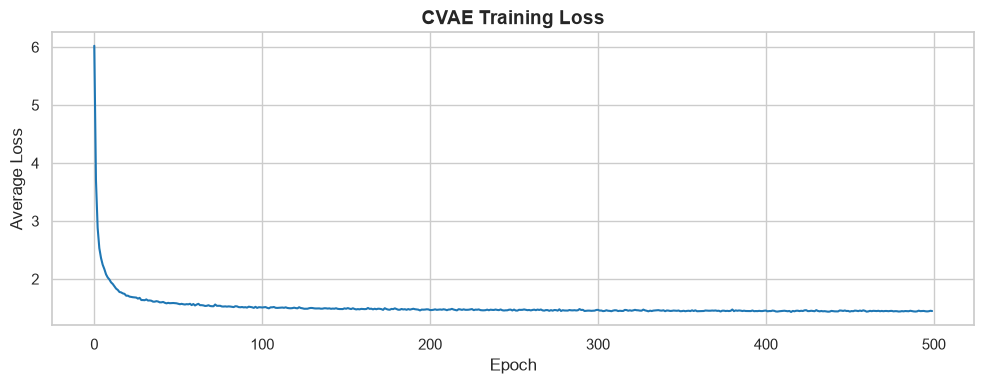

In [ ]:
# Prepare training data: anomalies from both domains
src_labels = np.zeros(len(src_scaled))
tgt_labels = np.ones(len(tgt_scaled))

X_train = np.vstack([src_scaled, tgt_scaled]).astype(np.float32)
c_train = np.concatenate([src_labels, tgt_labels]).astype(np.float32).reshape(-1, 1)

dataset = TensorDataset(torch.tensor(X_train), torch.tensor(c_train))
loader = DataLoader(dataset, batch_size=256, shuffle=True)

cvae_model = CVAE(input_dim=7, latent_dim=16, hidden_dim=64)
optimizer = optim.Adam(cvae_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500, eta_min=1e-5)

N_EPOCHS = 500
cvae_losses = []

cvae_model.train()
for epoch in tqdm(range(N_EPOCHS), desc="Training CVAE"):
    epoch_loss = 0
    for x_batch, c_batch in loader:
        optimizer.zero_grad()
        recon, mu, logvar = cvae_model(x_batch, c_batch)
        loss = cvae_loss(recon, x_batch, mu, logvar)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    cvae_losses.append(epoch_loss / len(X_train))

print(f"Final Loss: {cvae_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cvae_losses, color='#1f77b4', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Average Loss')
ax.set_title('CVAE Training Loss', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Analyzing the Learned Representations

Before using the CVAE as a generator, we inspect its latent space. In Stage 2, we saw that the Spring and Summer anomalies were far apart in the raw 7D sensor space. 

Because the domain label $c$ is explicitly fed to the decoder. This forces the encoder to strip the domain-specific environmental information out of the latent space $z$. The latent representations should therefore capture only the pure "failure physics," completely independent of the season. 

If the CVAE has successfully disentangled the failure from the environment, we expect the distance between Spring and Summer anomalies in the latent space to collapse to near zero.

In [ ]:
def mmd_rbf(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X, Y):
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False)
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if isinstance(covmean, tuple): covmean = covmean[0]
    if np.iscomplexobj(covmean): covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

def compute_distances(X, Y):
    swd = ot.sliced_wasserstein_distance(X, Y, n_projections=50)
    mmd = mmd_rbf(X, Y, gamma=0.1)
    fd = frechet_distance(X, Y)
    return {'SWD': swd, 'MMD': mmd, 'FD': fd}

def eval_bridging(synth_scaled, alpha_val):
    """Evaluate a set of synthetic anomalies: compute distances and TL penalty."""
    synth_raw = scaler.inverse_transform(synth_scaled)
    synth_df = pd.DataFrame(synth_raw, columns=ANALOG_SENSORS)
    synth_df['Anomaly'] = 1
    
    bridged = pd.concat([source_spring[ANALOG_SENSORS + ['Anomaly']], synth_df], ignore_index=True)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        bridged[ANALOG_SENSORS], bridged['Anomaly'], test_size=0.2, random_state=42)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    
    bl_f1 = f1_score(y_te, rf.predict(X_te), zero_division=0)
    tr_f1 = f1_score(target_summer['Anomaly'], rf.predict(target_summer[ANALOG_SENSORS]), zero_division=0)
    
    dist = compute_distances(np.vstack([src_scaled, synth_scaled]), tgt_scaled)
    
    return {
        'Alpha': alpha_val,
        'Baseline F1': bl_f1,
        'Transfer F1': tr_f1,
        'Transfer Penalty': bl_f1 - tr_f1,
        'SWD': dist['SWD'],
        'MMD': dist['MMD'],
        'FD': dist['FD']
    }

# Also compute the no-augmentation baseline
rf_noaug = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
X_tr_na, X_te_na, y_tr_na, y_te_na = train_test_split(
    source_spring[ANALOG_SENSORS], source_spring['Anomaly'], test_size=0.2, random_state=42)
rf_noaug.fit(X_tr_na, y_tr_na)
noaug_bl = f1_score(y_te_na, rf_noaug.predict(X_te_na), zero_division=0)
noaug_tr = f1_score(target_summer['Anomaly'], rf_noaug.predict(target_summer[ANALOG_SENSORS]), zero_division=0)
noaug_penalty = noaug_bl - noaug_tr

print(f"Baseline: F1={noaug_bl:.4f} -> Transfer F1={noaug_tr:.4f} | Penalty={noaug_penalty:.4f}")

alphas = np.arange(0.0, 1.1, 0.1)
N_SYNTHETIC = len(src_scaled)

Baseline: F1=0.9757 -> Transfer F1=0.4728 | Penalty=0.5030


In [ ]:
cvae_model.eval()
with torch.no_grad():
    mu_src, _ = cvae_model.encode(
        torch.tensor(src_scaled, dtype=torch.float32),
        torch.zeros(len(src_scaled), 1))
    mu_tgt, _ = cvae_model.encode(
        torch.tensor(tgt_scaled, dtype=torch.float32),
        torch.ones(len(tgt_scaled), 1))

latent_src = mu_src.numpy()
latent_tgt = mu_tgt.numpy()

latent_dist = compute_distances(latent_src, latent_tgt)
raw_dist = compute_distances(src_scaled, tgt_scaled)

dist_table = pd.DataFrame({
    'Raw Sensor Space (7D)': raw_dist,
    'CVAE Latent Space (16D)': latent_dist
}).T
print("=== Domain Distance: Raw Features vs. Learned Representations ===")
display(dist_table)


=== Domain Distance: Raw Features vs. Learned Representations ===


,SWD,MMD,FD
Raw Sensor Space (7D),1.070158,0.499926,8.186272
CVAE Latent Space (16D),0.077412,0.000711,0.048171


### 2.3 CVAE $\alpha$ Sweep

We now sweep the conditioning label $\alpha$ from 0.0 (pure Spring) to 1.0 (pure Summer) to generate synthetic anomalies that geometrically bridge the domain gap. 
For each $\alpha$ step, we:
1. **Generate**: Sample exactly $N = |Spring|$ synthetic anomalies to maintain a balanced 1:1 augmentation ratio.
2. **Measure**: Calculate the geometric distance (SWD, MMD, FD) between this **new augmented training set** and the true Target domain (Summer).
3. **Evaluate**: Train a Random Forest on the augmented set and test it on Summer to measure the Transfer Penalty.

This process allows us to show how the synthetic data generation can reduce the domain gap and improve transfer learning performance.


In [ ]:
cvae_results = []

cvae_model.eval()
for alpha in tqdm(alphas, desc="CVAE Sweep"):
    with torch.no_grad():
        z = torch.randn(N_SYNTHETIC, 16)
        c = torch.full((N_SYNTHETIC, 1), alpha)
        synth = cvae_model.decode(z, c).numpy()
    cvae_results.append(eval_bridging(synth, alpha))

cvae_df = pd.DataFrame(cvae_results)
print("\n=== CVAE Alpha Sweep ===")
display(cvae_df[['Alpha', 'Transfer Penalty', 'SWD', 'MMD', 'FD']])

CVAE Sweep: 100%|██████████| 11/11 [03:12<00:00, 17.50s/it]


=== CVAE Alpha Sweep ===


,Alpha,Transfer Penalty,SWD,MMD,FD
0,0.0,0.431395,1.006706,0.530790,7.372042
1,0.1,0.339501,0.900877,0.477229,6.793510
2,0.2,0.365550,0.950992,0.419151,6.193602
3,0.3,0.316334,0.868975,0.357607,5.627801
4,0.4,0.301879,0.825981,0.297536,4.941796
5,0.5,0.291087,0.787873,0.240599,4.317228
6,0.6,0.264746,0.803008,0.198043,3.832100
7,0.7,0.271255,0.822954,0.166608,3.377830
8,0.8,0.224204,0.736171,0.144123,2.971888
9,0.9,0.228857,0.715430,0.126675,2.669909


## 3. Conditional GAN (CGAN)
To prove that our domain-bridging strategy is robust, we replicate the experiment using a **Conditional GAN (CGAN)**. 

While the CVAE relies on reconstruction and probabilistic priors, the CGAN uses adversarial learning. If a different architecture produces a similar reduction in Transfer Penalty, it confirms that the success comes from the conditioning mechanism itself, rather than the specific generative model.

In [ ]:
class CGANGenerator(nn.Module):
    """Conditional GAN Generator: noise + domain label -> synthetic features."""
    def __init__(self, noise_dim=16, cond_dim=1, hidden_dim=64, output_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=1))

class CGANDiscriminator(nn.Module):
    """Conditional GAN Discriminator: features + domain label -> real/fake."""
    def __init__(self, input_dim=7, cond_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, c):
        return self.net(torch.cat([x, c], dim=1))

print("CGAN model defined.")
print("Generator:", CGANGenerator())
print("Discriminator:", CGANDiscriminator())

CGAN model defined.
Generator: CGANGenerator(
  (net): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=7, bias=True)
  )
)
Discriminator: CGANDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


### 4.1 Training the CGAN

We train the CGAN on the same data as the CVAE (all anomalies from both domains, labeled by season). We use standard GAN training hyperparameters: Adam with `lr=2e-4`, `betas=(0.5, 0.999)`, and label smoothing for stability.

Training CGAN: 100%|██████████| 500/500 [02:07<00:00,  3.91it/s]

Final G Loss: 0.7942 | D Loss: 1.3591


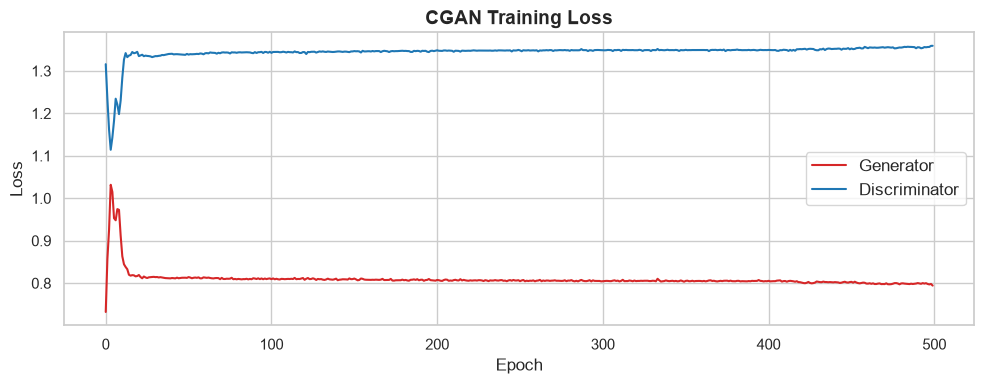

In [ ]:
NOISE_DIM = 16

gen = CGANGenerator(noise_dim=NOISE_DIM, hidden_dim=64, output_dim=7)
disc = CGANDiscriminator(input_dim=7, hidden_dim=64)

opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

bce = nn.BCELoss()

# Reuse the same dataset/loader from CVAE training
N_EPOCHS_GAN = 500
g_losses, d_losses = [], []

for epoch in tqdm(range(N_EPOCHS_GAN), desc="Training CGAN"):
    g_loss_epoch, d_loss_epoch = 0, 0
    
    for x_real, c_real in loader:
        batch_size = x_real.size(0)
        
        # Labels with smoothing
        real_label = torch.full((batch_size, 1), 0.9)
        fake_label = torch.zeros(batch_size, 1)
        
        # ── Train Discriminator ──
        opt_d.zero_grad()
        
        # Real samples
        d_real = disc(x_real, c_real)
        loss_real = bce(d_real, real_label)
        
        # Fake samples
        z = torch.randn(batch_size, NOISE_DIM)
        x_fake = gen(z, c_real).detach()
        d_fake = disc(x_fake, c_real)
        loss_fake = bce(d_fake, fake_label)
        
        d_loss = loss_real + loss_fake
        d_loss.backward()
        opt_d.step()
        
        # ── Train Generator ──
        opt_g.zero_grad()
        
        z = torch.randn(batch_size, NOISE_DIM)
        x_fake = gen(z, c_real)
        d_fake = disc(x_fake, c_real)
        g_loss = bce(d_fake, real_label)  # Generator wants disc to say "real"
        
        g_loss.backward()
        opt_g.step()
        
        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()
    
    n_batches = len(loader)
    g_losses.append(g_loss_epoch / n_batches)
    d_losses.append(d_loss_epoch / n_batches)

print(f"Final G Loss: {g_losses[-1]:.4f} | D Loss: {d_losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator', color='#d62728', linewidth=1.5)
ax.plot(d_losses, label='Discriminator', color='#1f77b4', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('CGAN Training Loss', fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 CGAN $\alpha$ Sweep

We perform the same $\alpha$ sweep as the CVAE: for each conditioning value, generate synthetic anomalies, augment the Spring training set, and measure the Transfer Penalty.

In [ ]:
cgan_results = []

gen.eval()
for alpha in tqdm(alphas, desc="CGAN Sweep"):
    with torch.no_grad():
        z = torch.randn(N_SYNTHETIC, NOISE_DIM)
        c = torch.full((N_SYNTHETIC, 1), alpha)
        synth = gen(z, c).numpy()
    cgan_results.append(eval_bridging(synth, alpha))

cgan_df = pd.DataFrame(cgan_results)
print("\n=== CGAN Alpha Sweep ===")
display(cgan_df[['Alpha', 'Transfer Penalty', 'SWD', 'MMD', 'FD']])

CGAN Sweep: 100%|██████████| 11/11 [03:05<00:00, 16.83s/it]


=== CGAN Alpha Sweep ===


,Alpha,Transfer Penalty,SWD,MMD,FD
0,0.0,0.443634,0.954963,0.497732,7.022975
1,0.1,0.318490,0.972695,0.427376,6.223843
2,0.2,0.310186,0.850142,0.361566,5.561739
3,0.3,0.322741,0.911524,0.301099,4.964172
4,0.4,0.307485,0.750725,0.247218,4.439783
5,0.5,0.286948,0.764740,0.209909,3.888650
6,0.6,0.184869,0.729017,0.182179,3.462205
7,0.7,0.135003,0.700605,0.160980,3.210050
8,0.8,0.109943,0.724723,0.145811,2.886155
9,0.9,0.071451,0.716252,0.132593,2.671804


## 4. Final Comparison: CVAE vs CGAN

We now plot the Transfer Penalty curves from both generative architectures on the same graph. The horizontal dashed line shows the **no-augmentation baseline** (~50% penalty) from Stage 2.

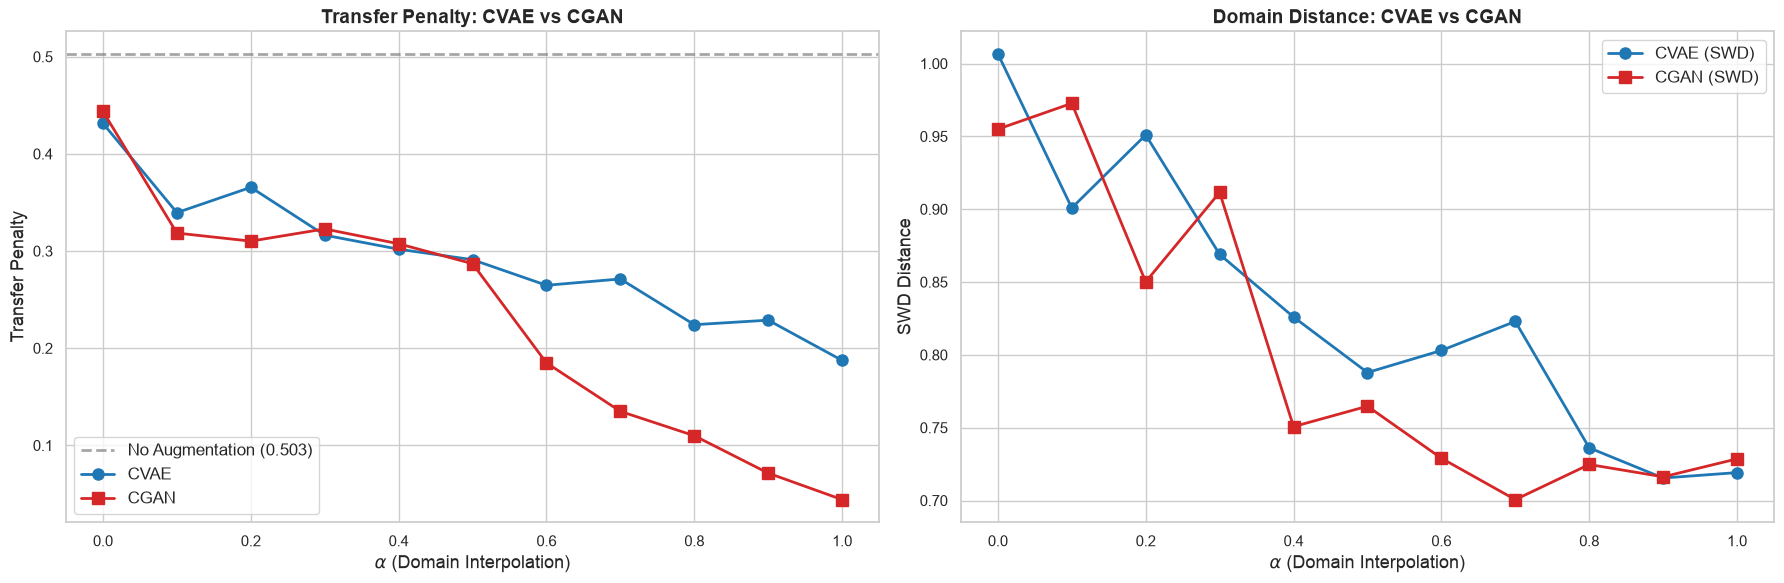


=== Summary ===


,Method,Best Alpha,Transfer Penalty
0,No Augmentation,-,0.502979
1,CVAE (best α),1.0,0.187436
2,CGAN (best α),1.0,0.044190


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Left: Transfer Penalty vs Alpha ──
axes[0].axhline(y=noaug_penalty, color='gray', linestyle='--', linewidth=2, alpha=0.7,
               label=f'No Augmentation ({noaug_penalty:.3f})')
axes[0].plot(cvae_df['Alpha'], cvae_df['Transfer Penalty'], 'o-', color='#1f77b4',
            linewidth=2, markersize=8, label='CVAE')
axes[0].plot(cgan_df['Alpha'], cgan_df['Transfer Penalty'], 's-', color='#d62728',
            linewidth=2, markersize=8, label='CGAN')
axes[0].set_xlabel('$\\alpha$ (Domain Interpolation)', fontsize=13)
axes[0].set_ylabel('Transfer Penalty', fontsize=13)
axes[0].set_title('Transfer Penalty: CVAE vs CGAN', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=12)

# ── Right: Distance vs Alpha (both models, SWD) ──
axes[1].plot(cvae_df['Alpha'], cvae_df['SWD'], 'o-', color='#1f77b4',
            linewidth=2, markersize=8, label='CVAE (SWD)')
axes[1].plot(cgan_df['Alpha'], cgan_df['SWD'], 's-', color='#d62728',
            linewidth=2, markersize=8, label='CGAN (SWD)')
axes[1].set_xlabel('$\\alpha$ (Domain Interpolation)', fontsize=13)
axes[1].set_ylabel('SWD Distance', fontsize=13)
axes[1].set_title('Domain Distance: CVAE vs CGAN', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Method': ['No Augmentation', 'CVAE (best \u03b1)', 'CGAN (best \u03b1)'],
    'Best Alpha': ['-', f"{cvae_df.loc[cvae_df['Transfer Penalty'].idxmin(), 'Alpha']:.1f}",
                   f"{cgan_df.loc[cgan_df['Transfer Penalty'].idxmin(), 'Alpha']:.1f}"],
    'Transfer Penalty': [noaug_penalty,
                         cvae_df['Transfer Penalty'].min(),
                         cgan_df['Transfer Penalty'].min()]
})
print("\n=== Summary ===")
display(summary)

# 5. Conclusion: Bridging Domain Gaps with Synthetic Data

We successfully proved that we can bridge this gap using **Domain-Conditioned Synthetic Data Generation**:

1. Both the CVAE and the CGAN show the exact same trend. As the domain parameter $\alpha$ shifts from 0.0 to 1.0, the geometric distance (SWD, MMD, FD) between the training set and the target set drops, which directly causes the Transfer Penalty to plummet.

2. While both models successfully learned to interpolate across the domain gap, the **CGAN significantly outperformed the CVAE**. Although both achieved a similar minimum geometric distance (SWD $\approx 0.72$), the adversarial training of the CGAN produced synthetic anomalies that were much more effective for the downstream Random Forest classifier, dropping the Transfer Penalty to a negligible **4.4%**. 

3. These results confirm that **domain distance** can be used as a proxy for **transfer learning performance**, and that **domain-conditioned synthetic data generation** is a powerful tool to bridge domain gaps in industrial datasets.